In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

подготовка данных

In [2]:
dataset = pd.read_csv("pricerunner_aggregate.csv")
dataset.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [3]:
print(dataset.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']


In [4]:
dataset = dataset.drop(' Category Label', axis = 1)

In [5]:
dataset = dataset.drop('Product Title', axis = 1)

In [6]:
dataset = dataset.drop('Product ID', axis = 1)

In [7]:
dataset = dataset.drop(' Cluster Label', axis = 1)

In [8]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,2612
1,2,1,2612
2,3,1,2612
3,4,1,2612
4,5,1,2612
...,...,...,...
35306,59,47517,2623
35307,59,47518,2623
35308,59,47519,2623
35309,125,47524,2623


In [9]:
dataset[' Category ID'] = pd.factorize(dataset[' Category ID'])[0]

In [10]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0
...,...,...,...
35306,59,47517,9
35307,59,47518,9
35308,59,47519,9
35309,125,47524,9


In [11]:
vals = dataset[" Category ID"].unique()
vals

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [12]:
from sklearn.model_selection import train_test_split

# Например, берем 10% данных с сохранением пропорций классов
dataset_small, _ = train_test_split(
    dataset,
    test_size=0.9,  # 90% отбрасываем, 10% оставляем
    stratify=dataset[' Category ID'],  # или твой целевой столбец с классами
    random_state=42
)

In [13]:
# сохраняем только числовые столбцы. Целевую переменную убираем
cols_for_clusters = [' Merchant ID',' Cluster ID']

df = dataset_small[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [14]:
df.head()

,Merchant ID,Cluster ID
3609,48,1384
10184,66,6715
6191,18,4770
33960,300,46629
26985,119,44124


In [15]:
X = df
y = dataset_small[" Category ID"].replace(vals, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
yvals = dataset[" Category ID"]

In [16]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

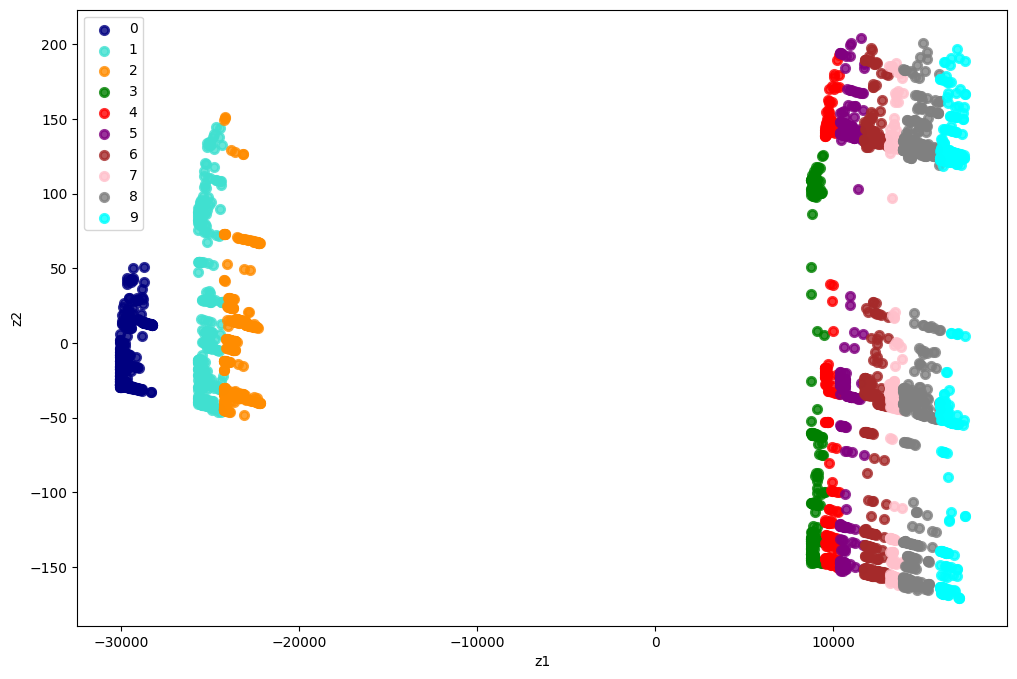

In [17]:
pca = PCA(n_components=2)
X_new = pca.fit_transform(X)

plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange", "green", "red", "purple", "brown", "pink", "gray", "cyan"]
lw = 2

for color, i, target_name in zip(colors, sorted(set(y)), sorted(set(y))):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

красиво смотрится, видно структуру данных

In [18]:
pca.explained_variance_ratio_

array([9.9996864e-01, 3.1359928e-05])

можно сказать, что признаки линейно друг от друга зависят

In [19]:
from sklearn.decomposition import FastICA

fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X)

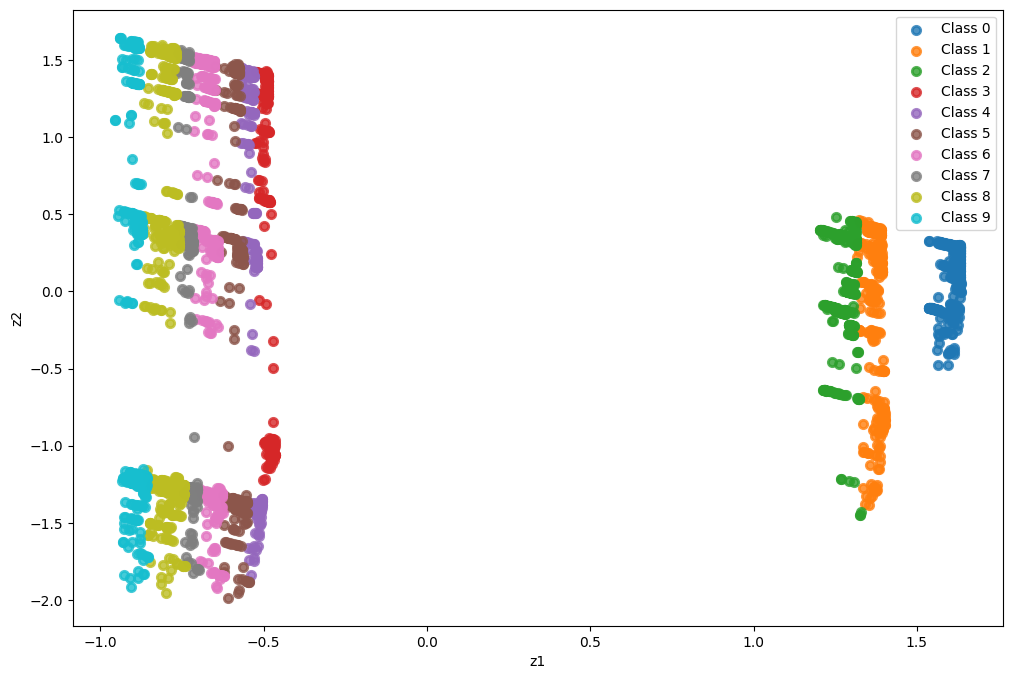

In [20]:
plt.figure(figsize=(12,8))

# Определяем уникальные классы из y
unique_classes = sorted(set(y))
# Генерируем colours под количество классов
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

for color, i in zip(colors, unique_classes):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1],
        color=color, alpha=0.8, lw=2, label=f'Class {i}'
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

нелинейные методы

In [21]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X)

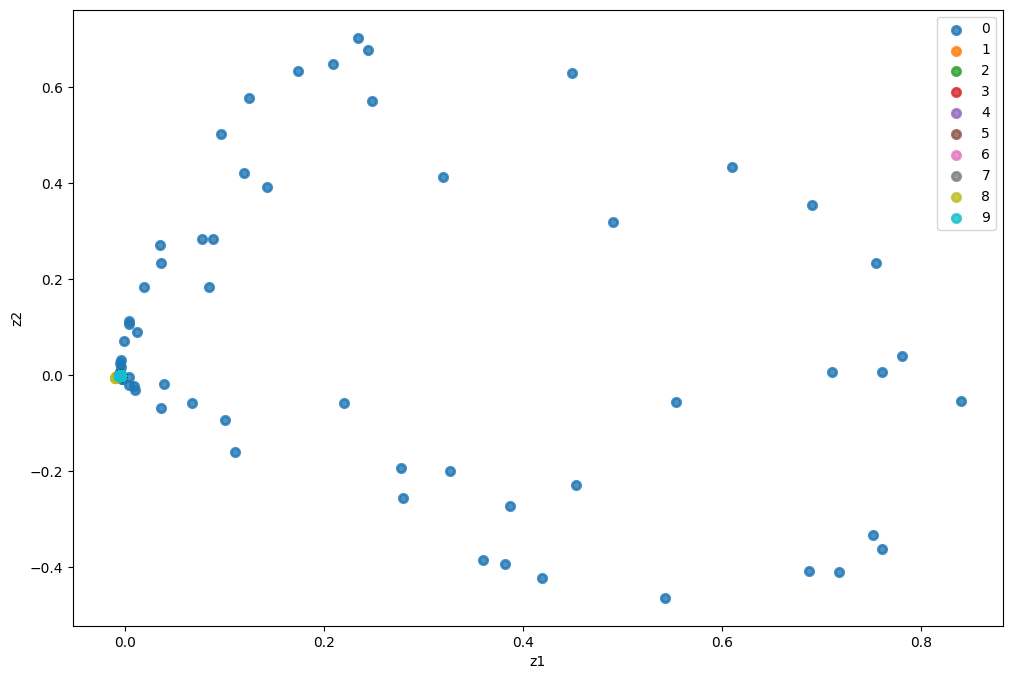

In [22]:
plt.figure(figsize=(12,8))

unique_classes = sorted(set(y))

colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

for color, i in zip(colors, unique_classes):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1],
        color=color, alpha=0.8, lw=2, label=i
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

как только ушли от линейных методов получилось не пойми что, очередное доказательство линейности данных

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_new = tsne.fit_transform(X)

In [24]:
# Вывод результатов
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)
#print('Embedding vectors: ', tsne.embedding_)

Initial Shape of X:  (3531, 2)
New Shape of X:  (3531, 2)
Kullback-Leibler divergence after optimization:  0.30470654368400574
No. of iterations:  999


значение получилось хорошее - 0.3, ну про данные и так уже все понятно, линейные максимально

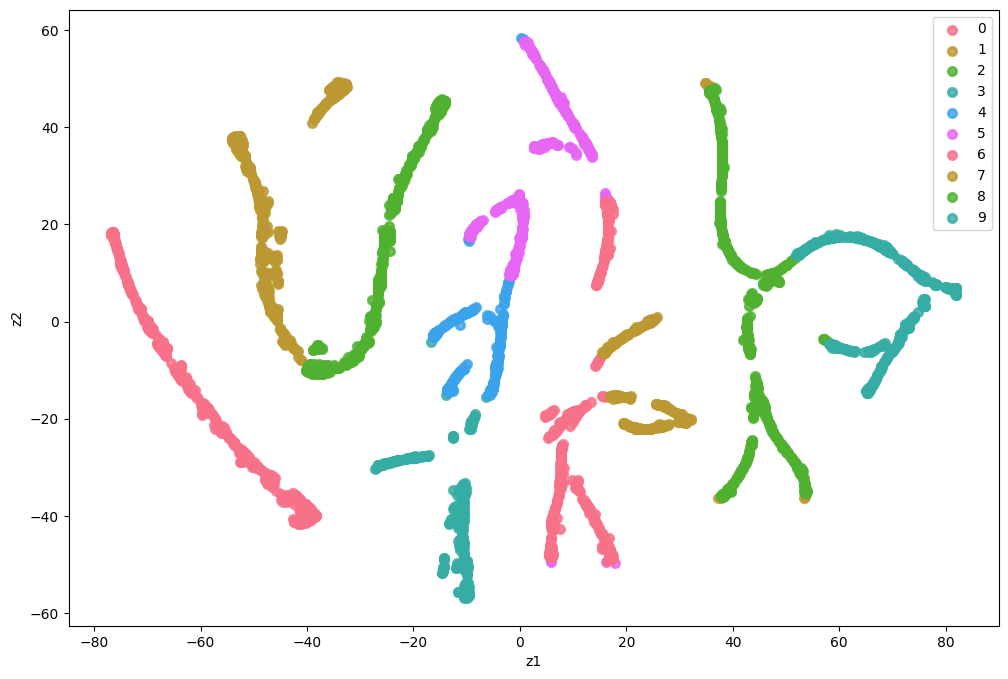

In [25]:
plt.figure(figsize=(12,8))

for i in sorted(set(y)):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1],
        alpha=0.8, lw=2, label=i
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

очередная визуализация

поиск выбросов

In [26]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [41]:
dbscan_cluster1 = DBSCAN(eps = 0.35, min_samples = 5)
X_new = dbscan_cluster1.fit(X)

In [42]:
# Number of Clusters
labels = dbscan_cluster1.labels_
N_clus = len(set(labels)) - (1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 3531
v_measure = 0.0


ну шума нет в данных, это здорово, но кластеров тоже нет

In [43]:
from sklearn.neighbors import NearestNeighbors

min_samples = 3

knn = NearestNeighbors(n_neighbors = min_samples, metric = 'l2')
knn.fit(X)

dists, inds = knn.kneighbors(X)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

In [44]:
import sklearn
#возможные метрики расстояния
sklearn.metrics.pairwise.distance_metrics()

{'cityblock': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'cosine': <function sklearn.metrics.pairwise.cosine_distances(X, Y=None)>,
 'euclidean': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'haversine': <function sklearn.metrics.pairwise.haversine_distances(X, Y=None)>,
 'l2': <function sklearn.metrics.pairwise.euclidean_distances(X, Y=None, *, Y_norm_squared=None, squared=False, X_norm_squared=None)>,
 'l1': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'manhattan': <function sklearn.metrics.pairwise.manhattan_distances(X, Y=None)>,
 'precomputed': None,
 'nan_euclidean': <function sklearn.metrics.pairwise.nan_euclidean_distances(X, Y=None, *, squared=False, missing_values=nan, copy=True)>}

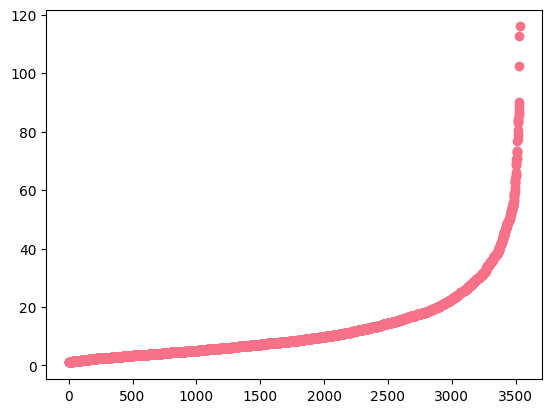

In [45]:
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

хорошо выглядит, изгиб примерно на 30

In [46]:
dbscan = DBSCAN(eps = 0.25, min_samples = 20)
print(dbscan)

DBSCAN(eps=0.25, min_samples=20)


In [47]:
pred = dbscan.fit_predict(X)

In [48]:
# Number of Clusters
labels=dbscan.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 3531
v_measure = 0.0


DBSCAN не хочет работать, ну ничего страшного, в принципе уже несколько раз убедились в линейности данных и отсутствии выбросов